In [2]:
import os
import re
import subprocess
from pathlib import Path

import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("imports OK")

imports OK


In [3]:
# making sure samtools is available 

import subprocess

subprocess.run(
    ["samtools", "--version"],
    check=True
)

samtools 1.23.1
Using htslib 1.23.1
Copyright (C) 2025 Genome Research Ltd.

Samtools compilation details:
    Features:       build=configure curses=yes 
    CC:             /opt/conda/conda-bld/samtools_1773861632090/_build_env/bin/x86_64-conda-linux-gnu-cc
    CPPFLAGS:       -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /samurlab1/Joshua/joshMiniforge3/envs/nextflow/include
    CFLAGS:         -Wall -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /samurlab1/Joshua/joshMiniforge3/envs/nextflow/include -fdebug-prefix-map=/opt/conda/conda-bld/samtools_1773861632090/work=/usr/local/src/conda/samtools-1.23.1 -fdebug-prefix-map=/samurlab1/Joshua/joshMiniforge3/envs/nextflow=/usr/local/src/conda-prefix
    LDFLAGS:        -Wl,-O2 -Wl,--sort-common -Wl,--as-needed -Wl,-z,relro -Wl,-z,now -Wl,--disable-new-dtags -Wl,--gc-sections -Wl,--allow-shlib-undefined -Wl,-rpath,/samurlab1/Joshua/joshMiniforge3/envs/nextflow/lib 

CompletedProcess(args=['samtools', '--version'], returncode=0)

In [4]:
fig_dir = Path("../results/figures")
table_dir = Path("../results/tables")

fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

# Quality Control Strategy

The primary objective of the quality control (QC) analysis is to evaluate the technical reliability, molecular complexity, and alignment behavior of the targeted small RNA-seq dataset prior to downstream biological interpretation. Because the data are provided as aligned BAM files, the QC workflow focuses on alignment-level and molecule-level characteristics rather than raw base quality metrics alone.

## Alignment-Level QC

Initial QC assessment evaluates the overall structure and integrity of the sequencing data, including:

- Total sequencing depth
- Fraction of mapped and uniquely mapped reads
- Mapping quality (MAPQ) distributions
- Read length distributions
- Chromosomal alignment patterns
- Target enrichment efficiency
- Coverage uniformity across targeted regions

This is a targeted sequencing enrichment strategy so we should check for sparse off-target coverage and localized high-depth enrichment. 


In [5]:
bam_dir = Path("../data/bam")

bam_files = sorted(bam_dir.glob("*.bam"))

bam_files

[PosixPath('../data/bam/sample1.bam'),
 PosixPath('../data/bam/sample2.bam'),
 PosixPath('../data/bam/sample3.bam')]

In [6]:
for bam in bam_files:

    print("=" * 80) # this is a separator for better readability of the output
    print(bam.name)
    print("=" * 80)

    result = subprocess.run(
        ["samtools", "flagstat", str(bam)],
        capture_output=True,
        text=True
    )

    print(result.stdout[:1500])

sample1.bam
1453538 + 0 in total (QC-passed reads + QC-failed reads)
1443266 + 0 primary
10272 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
1453538 + 0 mapped (100.00% : N/A)
1443266 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)

sample2.bam
1171294 + 0 in total (QC-passed reads + QC-failed reads)
1146078 + 0 primary
25216 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
1171294 + 0 mapped (100.00% : N/A)
1146078 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)

sample3.bam
1816

In [7]:
bam = pysam.AlignmentFile(bam_files[0], "rb")

for i, read in enumerate(bam.fetch(until_eof=True)):

    print("\n" + "="*70)
    print("READ NAME:", read.query_name)
    print("FLAG:", read.flag)
    print("REFERENCE:", read.reference_name)
    print("START:", read.reference_start)
    print("MAPQ:", read.mapping_quality)
    print("CIGAR:", read.cigarstring)
    print("READ LENGTH:", read.query_length)
    print("IS PAIRED:", read.is_paired)
    print("IS SECONDARY:", read.is_secondary)
    print("IS SUPPLEMENTARY:", read.is_supplementary)

    try:
        print("MB TAG:", read.get_tag("mb"))
    except KeyError:
        print("MB TAG: NOT FOUND")

    print("ALL TAGS:", read.get_tags())

    if i >= 5:
        break


READ NAME: NB501618:163:HWFCNAFXX:2:11308:8837:18047
FLAG: 64
REFERENCE: 1
START: 859010
MAPQ: 255
CIGAR: 1S70M8S
READ LENGTH: 79
IS PAIRED: False
IS SECONDARY: False
IS SUPPLEMENTARY: False
MB TAG: AAGAGTCA
ALL TAGS: [('NH', 1), ('HI', 1), ('AS', 68), ('nM', 0), ('mb', 'AAGAGTCA'), ('dg', 0), ('pe', 'unassigned'), ('te', 0), ('re', 1)]

READ NAME: NB501618:163:HWFCNAFXX:2:11308:8837:18047
FLAG: 144
REFERENCE: 1
START: 859010
MAPQ: 255
CIGAR: 70M8S
READ LENGTH: 78
IS PAIRED: False
IS SECONDARY: False
IS SUPPLEMENTARY: False
MB TAG: AAGAGTCA
ALL TAGS: [('NH', 1), ('HI', 1), ('AS', 68), ('nM', 0), ('mb', 'AAGAGTCA'), ('dg', 0), ('ps', 'unassigned'), ('ts', 0), ('rs', 1)]

READ NAME: NB501618:163:HWFCNAFXX:1:21104:17028:20107
FLAG: 384
REFERENCE: 1
START: 970552
MAPQ: 0
CIGAR: 1S18M
READ LENGTH: 19
IS PAIRED: False
IS SECONDARY: True
IS SUPPLEMENTARY: False
MB TAG: AACGGCGC
ALL TAGS: [('NH', 5), ('HI', 4), ('AS', 17), ('nM', 0), ('mb', 'AACGGCGC'), ('dg', 147), ('pe', 'unassigned'), ('te

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai


### Initial Observations from Read-Level BAM Inspection

Inspection of representative BAM records confirmed that the dataset consists of single-end alignments containing embedded molecular barcode annotations (`mb` tag). Multiple alignment characteristics were observed, including:

- High-confidence uniquely mapped reads (`NH=1`, `MAPQ=255`)
- Secondary/multimapping reads with low mapping quality (`MAPQ=0–3`)
- Frequent soft-clipped sequence segments (e.g. `1S70M8S`, `14M4D127M9S`)
- Variable read lengths ranging from very short fragments (~19 bp) to longer alignments (~150 bp)
- Occasional indel-containing alignments (e.g. `4D` in CIGAR strings)

The presence of secondary alignments and multimapping behavior is expected in small RNA sequencing due to short read lengths and homologous genomic regions. Soft clipping appears relatively common in the initial inspection and will be explored systematically later in the analysis to determine whether it reflects technical artifacts, RNA processing events, or structurally complex alignments.

The `mb` barcode tag appears consistently populated across reads, supporting downstream molecule-aware deduplication and PCR complexity analysis.

#### The `mb` barcode tag will be used for molecule-aware deduplication and estimation of library complexity, allowing comparison between raw read counts and unique barcode-supported molecules.

#### Final note: recurrent soft-clipped terminal sequences (~8 nt clipped regions) will be investigated further to determine whether they represent technical artifacts (adapter remnants, incomplete trimming, alignment ambiguity) or biologically meaningful content.

In [8]:
rows = []

for bam_file in bam_files:
    sample = bam_file.stem
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    for read in bam.fetch(until_eof=True):
        rows.append({
            "sample": sample,
            "read_length": read.query_length,
            "mapq": read.mapping_quality,
            "secondary": read.is_secondary
        })

read_df = pd.DataFrame(rows)

read_df.head()

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


,sample,read_length,mapq,secondary
0,sample1,79,255,False
1,sample1,78,255,False
2,sample1,19,0,True
3,sample1,128,255,False
4,sample1,130,255,False


In [9]:
read_df.to_csv(table_dir / "read_level_qc_table.csv", index=False)

In [10]:
read_summary = (
    read_df
    .groupby("sample")
    .agg(
        n_alignments=("read_length", "size"),
        median_read_length=("read_length", "median"),
        mean_read_length=("read_length", "mean"),
        median_mapq=("mapq", "median"),
        mean_mapq=("mapq", "mean"),
        secondary_fraction=("secondary", "mean")
    )
    .reset_index()
)

read_summary.to_csv(table_dir / "read_level_qc_summary.csv", index=False)

read_summary

,sample,n_alignments,median_read_length,mean_read_length,median_mapq,mean_mapq,secondary_fraction
0,sample1,1453538,95.0,94.010130,255.0,251.715196,0.007067
1,sample2,1171294,99.0,97.259549,255.0,244.578482,0.021528
2,sample3,1816522,99.0,97.169312,255.0,252.074146,0.006280


In [11]:
qc_df = read_summary.copy()

qc_df["secondary_alignments"] = (
    qc_df["n_alignments"] * qc_df["secondary_fraction"]
).round().astype(int)

qc_df["primary_alignments"] = qc_df["n_alignments"] - qc_df["secondary_alignments"]

qc_df

,sample,n_alignments,median_read_length,mean_read_length,median_mapq,mean_mapq,secondary_fraction,secondary_alignments,primary_alignments
0,sample1,1453538,95.0,94.010130,255.0,251.715196,0.007067,10272,1443266
1,sample2,1171294,99.0,97.259549,255.0,244.578482,0.021528,25216,1146078
2,sample3,1816522,99.0,97.169312,255.0,252.074146,0.006280,11408,1805114


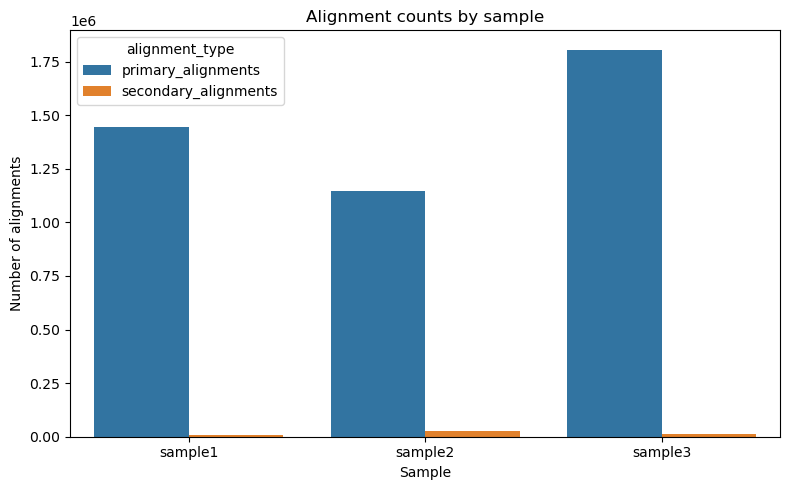

In [12]:
qc_plot = qc_df.melt(
    id_vars="sample",
    value_vars=[
        "primary_alignments",
        "secondary_alignments"
    ],
    var_name="alignment_type",
    value_name="count"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=qc_plot,
    x="sample",
    y="count",
    hue="alignment_type"
)

plt.title("Alignment counts by sample")
plt.ylabel("Number of alignments")
plt.xlabel("Sample")

plt.tight_layout()

plt.savefig(fig_dir / "alignment_counts_by_sample.png", dpi=300, bbox_inches="tight")

plt.show()

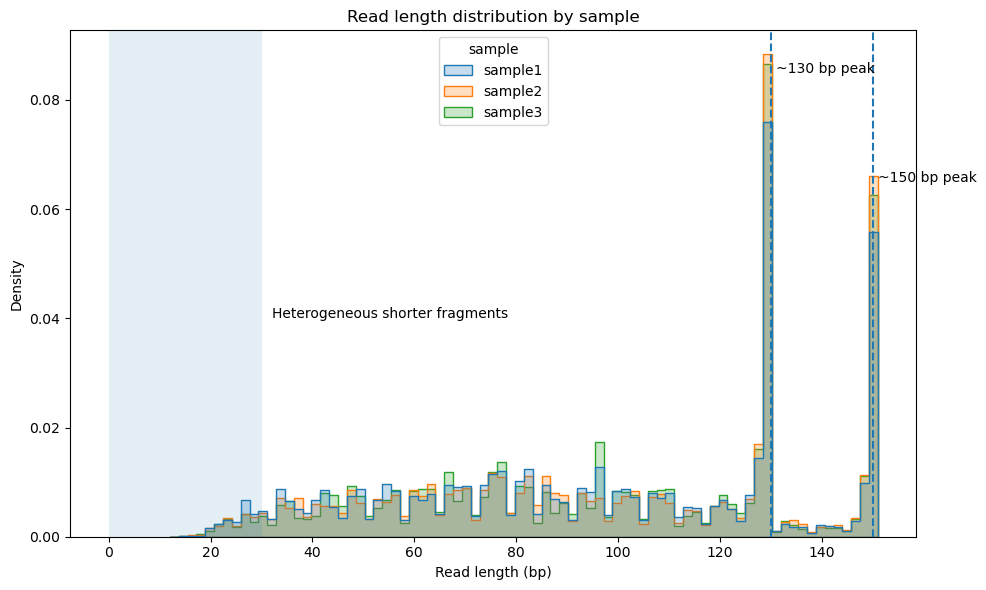

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=read_df,
    x="read_length",
    hue="sample",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)

plt.axvspan(0, 30, alpha=0.12, label="Short fragment region (<30 bp)")
plt.axvline(130, linestyle="--")
plt.axvline(150, linestyle="--")

plt.text(32, 0.04, "Heterogeneous shorter fragments")
plt.text(131, 0.085, "~130 bp peak")
plt.text(151, 0.065, "~150 bp peak")

plt.title("Read length distribution by sample")
plt.xlabel("Read length (bp)")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(fig_dir / "read_length_distribution_by_sample.png", dpi=300, bbox_inches="tight")

plt.show()

#### Read length distributions showed prominent enrichment peaks around ~130 bp and ~150 bp across all three samples. While histogram density alone does not directly measure biological signal strength, these distributions help characterize the dominant fragment populations present within the targeted sequencing assay.

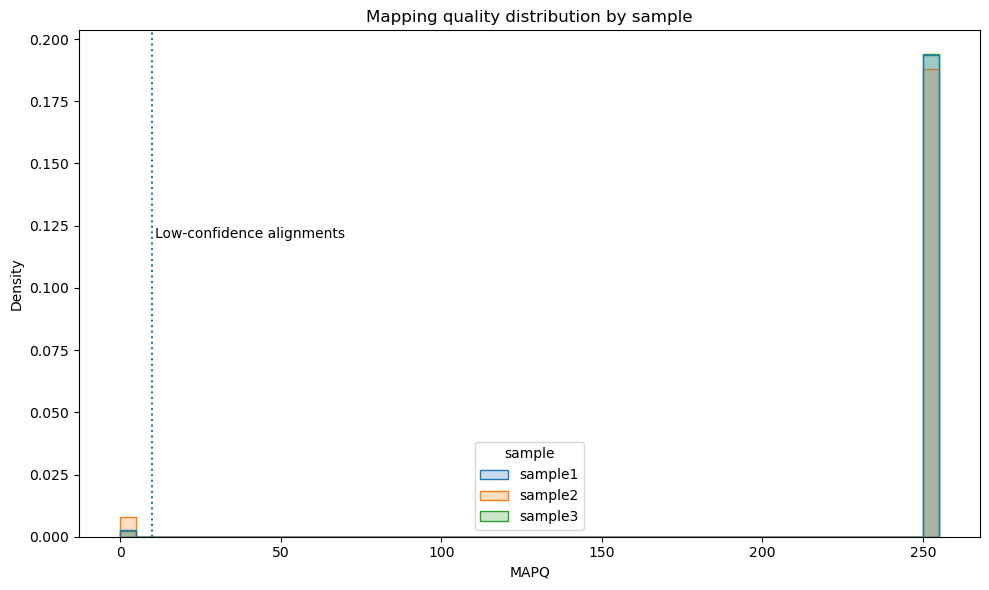

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=read_df,
    x="mapq",
    hue="sample",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.axvline(10, linestyle=":")
plt.text(11, 0.12, "Low-confidence alignments")

plt.title("Mapping quality distribution by sample")
plt.xlabel("MAPQ")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(fig_dir / "mapq_distribution_by_sample.png", dpi=300, bbox_inches="tight")

plt.show()

### Mapping Quality Distribution

I examined the distribution of mapping quality (MAPQ) scores across all samples. \

Across all three samples, the majority of alignments clustered at high MAPQ values (`MAPQ=255`) - thats good. That is consistent with predominantly unique or high-confidence alignments. 

The distribution clustering around zero are the few low confidence mapping alignment. this distribution corroborates a targeted enrichment modality.

Overall, the MAPQ distributions support a succesfful targeted sequencing enrichment strategy at this level.


## Molecule-Aware QC Using `mb` Barcodes

Reads contain an 8-mer molecular barcode stored in the `mb` BAM tag. These barcodes are used to estimate unique originating molecules and assess potential PCR amplification bias.

Both:
- raw aligned read counts, and
- barcode-deduplicated molecule counts

will be evaluated throughout the analysis. Comparing these two quantities enables estimation of:
- library complexity,
- amplification redundancy,
- and overrepresentation of highly amplified fragments.

This molecule-aware approach provides a more accurate estimate of true molecular abundance than raw sequencing depth alone.


In [15]:
barcode_rows = []

for bam_file in bam_files:
    sample = bam_file.stem
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    for read in bam.fetch(until_eof=True):
        if read.is_secondary:
            continue
        
        try:
            barcode = read.get_tag("mb")
        except KeyError:
            barcode = None
        
        barcode_rows.append({
            "sample": sample,
            "barcode": barcode
        })

barcode_df = pd.DataFrame(barcode_rows)

barcode_df.head()

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


,sample,barcode
0,sample1,AAGAGTCA
1,sample1,AAGAGTCA
2,sample1,CCGGTTTT
3,sample1,GACACGCG
4,sample1,AACGGGCC


In [16]:
barcode_summary = (
    barcode_df
    .groupby("sample")
    .agg(
        primary_alignments=("barcode", "size"),
        unique_barcodes=("barcode", "nunique")
    )
    .reset_index()
)

barcode_summary["reads_per_barcode"] = (
    barcode_summary["primary_alignments"] / barcode_summary["unique_barcodes"]
)

barcode_summary.to_csv(table_dir / "barcode_complexity_summary.csv", index=False)

barcode_summary

,sample,primary_alignments,unique_barcodes,reads_per_barcode
0,sample1,1443266,65295,22.103775
1,sample2,1146078,62133,18.445560
2,sample3,1805114,18823,95.899378


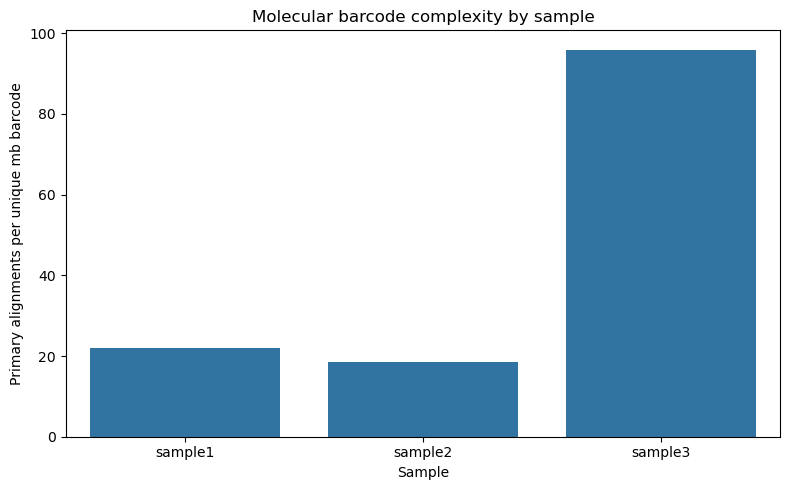

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=barcode_summary,
    x="sample",
    y="reads_per_barcode"
)

plt.title("Molecular barcode complexity by sample")
plt.xlabel("Sample")
plt.ylabel("Primary alignments per unique mb barcode")

plt.tight_layout()
plt.savefig(fig_dir / "barcode_complexity_by_sample.png", dpi=300, bbox_inches="tight")
plt.show()

### Molecular Barcode Complexity

I evaluated molecular barcode complexity using the `mb` tag embedded within the BAM records. For each sample, I compared the number of primary alignments to the number of unique molecular barcodes observed.

Samples 1 and 2 showed relatively similar reads-per-barcode ratios, suggesting comparable molecular complexity and amplification behavior. In contrast, sample3 demonstrated a substantially elevated reads-per-barcode ratio, indicating either reduced molecular diversity or increased amplification redundancy relative to the other samples.

This observation suggests that raw read depth alone may overestimate the number of unique originating molecules in sample3, reinforcing the importance of barcode-aware deduplication in downstream enrichment analyses.

### QC Summary

Across all three samples, alignment-level QC demonstrated highly consistent sequencing structure and targeted enrichment behavior. The majority of reads aligned with high confidence (`MAPQ=255`), while only a relatively small fraction of reads exhibited low-confidence or multimapping characteristics.

Read length distributions were highly reproducible between samples and showed prominent enrichment peaks around ~130 bp and ~150 bp, suggesting non-random fragment populations generated by the targeted sequencing assay. Shorter heterogeneous fragments were also present but represented a minority of total alignments.

Inspection of BAM records identified embedded molecular barcode annotations (`mb` tags), enabling molecule-aware complexity analysis. Barcode-aware QC demonstrated that samples 1 and 2 exhibited relatively similar molecular complexity profiles, **whereas sample3 showed substantially elevated reads-per-barcode ratios, suggesting increased amplification redundancy or reduced molecular diversity.**

Collectively, these findings support a technically successful targeted sequencing dataset with strong alignment confidence, reproducible fragment architecture, and meaningful molecule-level differences between samples that should be accounted for in downstream enrichment analyses.